In [1]:
import sys
print(sys.version)

3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]


In [12]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [2]:
from typing import List, Tuple
import numpy as np
from torch.utils.data import Dataset
from torchvision import datasets, transforms

## Global Constants

In [3]:
DATA_DIR = "./data"
SEED = 42


## Dataset Loader

    """
    Load and preprocess a dataset for federated learning.

    Parameters
    ----------
    name : str
        Name of the dataset ("MNIST" )

    Returns
    -------
    train_ds : Dataset
        Training dataset with normalization applied
    test_ds : Dataset
        Test dataset with normalization applied

    Raises
    ------
    ValueError
        If the dataset name is unsupported
    """

In [4]:
def get_dataset(name):
    if name == "MNIST":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        train_ds = datasets.MNIST(
            root=DATA_DIR, train=True, download=True, transform=transform
        )
        test_ds = datasets.MNIST(
            root=DATA_DIR, train=False, download=True, transform=transform
        )
    elif name == "EMNIST":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        train_ds = datasets.EMNIST(
            root=DATA_DIR, split='byclass', train=True, download=True, transform=transform
        )
        test_ds = datasets.EMNIST(
            root=DATA_DIR, split='byclass', train=False, download=True, transform=transform
        )
    else:
        raise ValueError(f"Unsupported dataset: {name}")

    return train_ds, test_ds

## IID Dataset Split

    """
    Create IID (Independent and Identically Distributed) data partitions.

    Each client receives approximately the same number of randomly
    selected samples.

    Parameters
    ----------
    dataset : Dataset
        PyTorch dataset to be partitioned
    num_clients : int
        Number of federated clients
    seed : int
        Random seed for reproducibility

    Returns
    -------
    List[List[int]]
        List of sample indices for each client
    """

In [5]:
def split_iid(dataset, num_clients, seed = SEED):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    splits = np.array_split(indices, num_clients)
    return [split.tolist() for split in splits]

## Non-IID Data Split (Shard-based)

Non-IID data is required because federated learning is designed to operate in environments where IID assumptions are false. Using only IID data gives a clean but unrealistic picture of system behavior.

    """
    Create Non-IID data partitions using shard-based partitioning.

    Each client receives data biased toward a small subset of classes,
    simulating statistical heterogeneity.

    Parameters
    ----------
    dataset : Dataset
        PyTorch dataset to be partitioned
    num_clients : int
        Number of federated clients
    shards_per_client : int
        Number of class-biased shards per client
    seed : int
        Random seed for reproducibility

    Returns
    -------
    List[List[int]]
        List of sample indices for each client
    """


In [6]:
def split_noniid_shard(
    dataset,
    num_clients,
    shards_per_client = 2,
    seed = SEED
):
    rng = np.random.default_rng(seed)
    labels = np.array(dataset.targets)
    indices = np.arange(len(dataset))

    # Sort samples by label to form homogeneous shards
    sorted_indices = indices[np.argsort(labels)]

    num_shards = num_clients * shards_per_client
    shard_size = len(dataset) // num_shards

    shards = [
        sorted_indices[i * shard_size:(i + 1) * shard_size]
        for i in range(num_shards)
    ]

    rng.shuffle(shards)

    client_indices = []
    for i in range(num_clients):
        client_shards = shards[i * shards_per_client:(i + 1) * shards_per_client]
        client_indices.append(np.concatenate(client_shards).tolist())

    return client_indices

## Partition Selector

    """
    Create client data partitions based on configuration.

    Parameters
    ----------
    dataset : Dataset
        Training dataset
    cfg : object
        Federated Learning configuration object with attributes:
        - num_clients (int)
        - iid (bool)
        - shards_per_client (int, optional)

    Returns
    -------
    List[List[int]]
        Client-wise data partitions
    """

In [7]:
def create_partitions(dataset, cfg):
    if cfg.iid:
        return split_iid(dataset, cfg.num_clients)
    else:
        return split_noniid_shard(
            dataset,
            cfg.num_clients,
            cfg.shards_per_client
        )

## Diagnostic Utility

    """
    Print label distribution for each client.

    Parameters
    ----------
    dataset : Dataset
        Dataset containing labels
    partitions : List[List[int]]
        Client-wise data indices
    """

In [9]:
def print_client_data_stats(dataset, partitions):
    labels = np.array(dataset.targets)
    for cid, idxs in enumerate(partitions):
        unique, counts = np.unique(labels[idxs], return_counts=True)
        stats = dict(zip(unique.tolist(), counts.tolist()))
        print(f"Client {cid}: {stats}")

In [10]:
# Load MNIST
train_ds, test_ds = get_dataset("MNIST")

# Test IID split
iid_partitions = split_iid(train_ds, num_clients=10)

print(f"Number of clients: {len(iid_partitions)}")
print(f"Samples per client: {[len(p) for p in iid_partitions]}")

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 118kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]

Number of clients: 10
Samples per client: [6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]


In [13]:
# Test Non-IID split
noniid_partitions = split_noniid_shard(train_ds, num_clients=10, shards_per_client=2)

print("Non-IID split:")
print(f"Samples per client: {[len(p) for p in noniid_partitions]}")
print()
print("Class distribution per client:")
print_client_data_stats(train_ds, noniid_partitions)

Non-IID split:
Samples per client: [6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]

Class distribution per client:
Client 0: {4: 3000, 7: 3000}
Client 1: {3: 3000, 7: 3000}
Client 2: {4: 596, 5: 2421, 6: 2983}
Client 3: {2: 623, 3: 2377, 9: 3000}
Client 4: {0: 3000, 1: 3000}
Client 5: {2: 3000, 7: 200, 8: 2800}
Client 6: {5: 3000, 8: 51, 9: 2949}
Client 7: {1: 3665, 2: 2335}
Client 8: {0: 2923, 1: 77, 8: 3000}
Client 9: {3: 754, 4: 2246, 6: 2935, 7: 65}


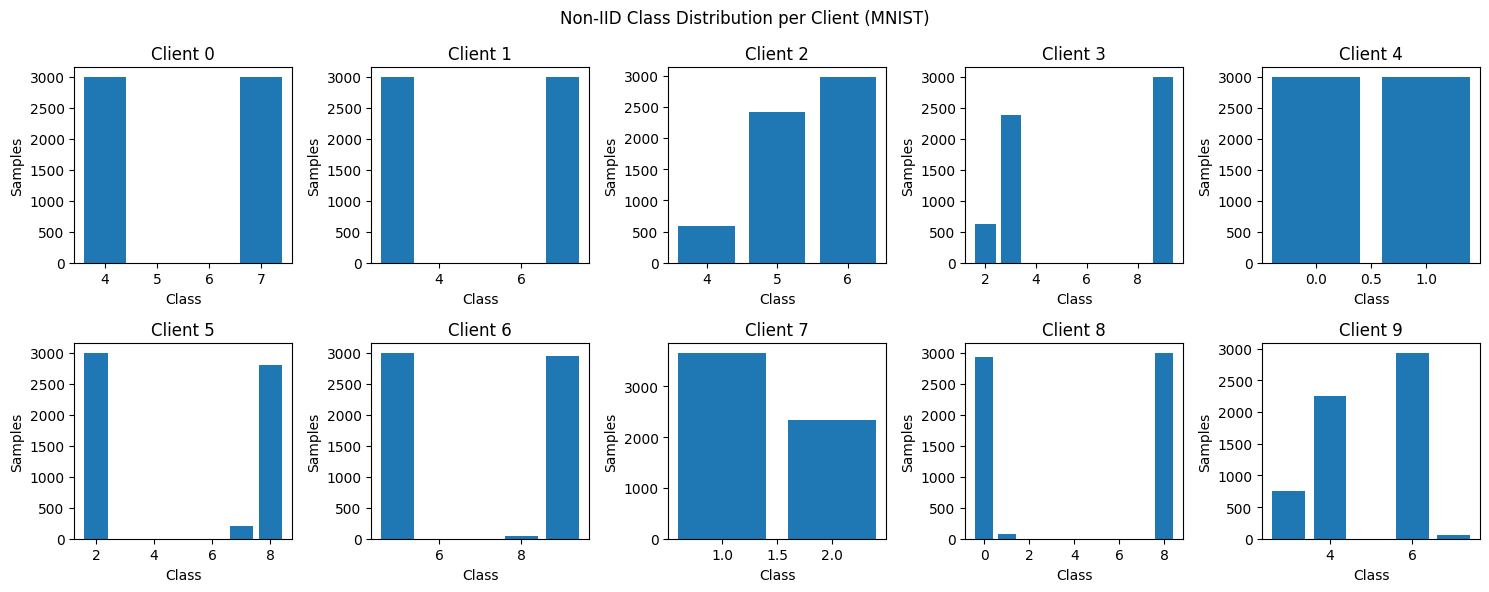

In [14]:
import matplotlib.pyplot as plt
import numpy as np

labels = np.array(train_ds.targets)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    idxs = noniid_partitions[i]
    client_labels = labels[idxs]
    unique, counts = np.unique(client_labels, return_counts=True)
    ax.bar(unique, counts)
    ax.set_title(f'Client {i}')
    ax.set_xlabel('Class')
    ax.set_ylabel('Samples')

plt.suptitle('Non-IID Class Distribution per Client (MNIST)')
plt.tight_layout()
plt.show()

## For EMNIST

In [15]:
# Load EMNIST
train_ds_emnist, test_ds_emnist = get_dataset("EMNIST")

# IID split
iid_partitions_emnist = split_iid(train_ds_emnist, num_clients=10)

print(f"Number of clients: {len(iid_partitions_emnist)}")
print(f"Samples per client: {[len(p) for p in iid_partitions_emnist]}")

100%|██████████| 562M/562M [03:27<00:00, 2.71MB/s] 


Number of clients: 10
Samples per client: [69794, 69794, 69793, 69793, 69793, 69793, 69793, 69793, 69793, 69793]


In [16]:
# Non-IID split
noniid_partitions_emnist = split_noniid_shard(train_ds_emnist, num_clients=10, shards_per_client=2)

print("Non-IID Class Distribution per Client (EMNIST):")
print_client_data_stats(train_ds_emnist, noniid_partitions_emnist)

Non-IID Class Distribution per Client (EMNIST):
Client 0: {9: 30971, 10: 3925, 32: 338, 33: 2771, 34: 4743, 35: 2701, 36: 10033, 37: 5159, 38: 2854, 39: 6297}
Client 1: {7: 32970, 8: 1926, 28: 3480, 29: 9820, 30: 12602, 31: 4637, 32: 4357}
Client 2: {10: 2482, 11: 3878, 12: 10094, 13: 4562, 14: 4934, 15: 8946, 22: 3263, 23: 8237, 24: 23396}
Client 3: {6: 32112, 7: 2784, 54: 297, 55: 18262, 56: 2830, 57: 2910, 58: 2697, 59: 2822, 60: 2365, 61: 2713}
Client 4: {0: 34585, 1: 311, 2: 2474, 3: 32422}
Client 5: {4: 1360, 5: 31416, 6: 2120, 39: 3880, 40: 24631, 41: 2561, 42: 3687, 43: 137}
Client 6: {15: 236, 16: 2517, 17: 3152, 18: 11946, 19: 3762, 20: 2468, 21: 5076, 22: 5739, 49: 10198, 50: 2749, 51: 2448, 52: 2994, 53: 14105, 54: 2402}
Client 7: {1: 3167, 2: 31729, 3: 2721, 4: 32175}
Client 8: {1: 34896, 43: 8601, 44: 2725, 45: 1896, 46: 2491, 47: 15318, 48: 2645, 49: 1220}
Client 9: {8: 32020, 9: 2876, 24: 1587, 25: 8347, 26: 2605, 27: 5073, 28: 17284}


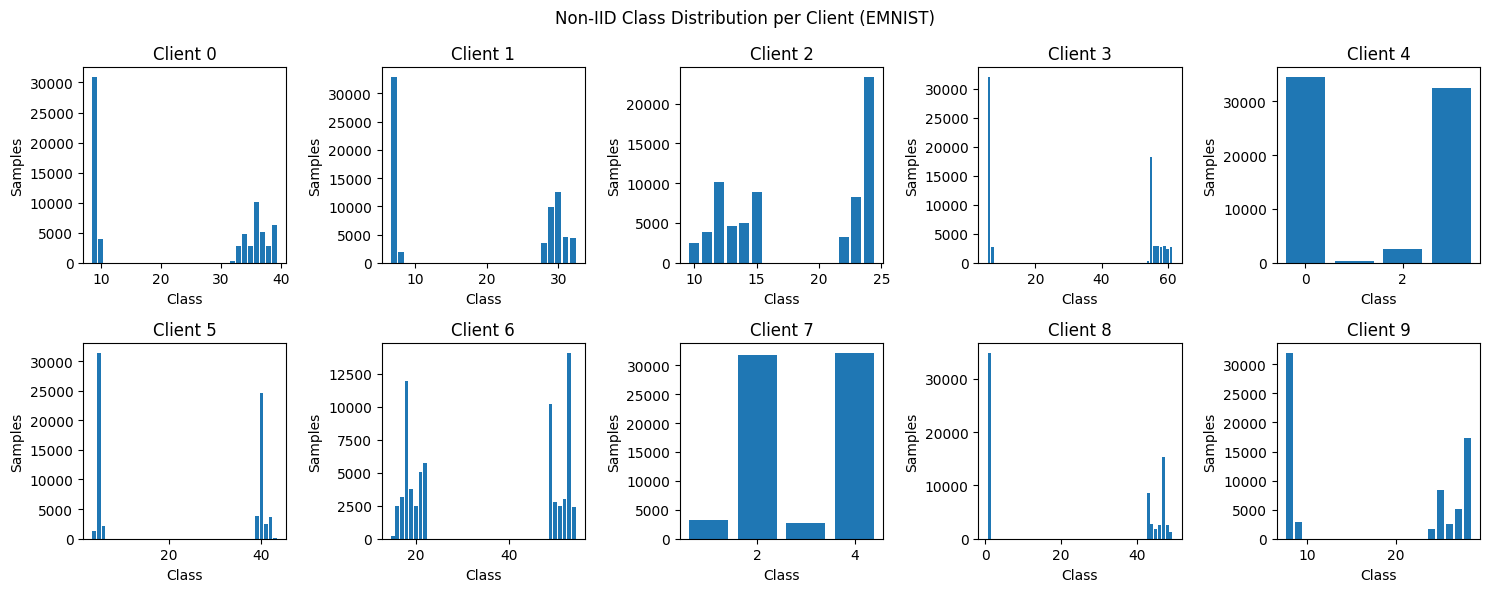

In [17]:
labels_emnist = np.array(train_ds_emnist.targets)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    idxs = noniid_partitions_emnist[i]
    client_labels = labels_emnist[idxs]
    unique, counts = np.unique(client_labels, return_counts=True)
    ax.bar(unique, counts)
    ax.set_title(f'Client {i}')
    ax.set_xlabel('Class')
    ax.set_ylabel('Samples')

plt.suptitle('Non-IID Class Distribution per Client (EMNIST)')
plt.tight_layout()
plt.show()